# Sensor Analysis - NASA C-MAPSS

In this notebook, we analyze the behavior of sensor signals in the FD001 training dataset.

The goal is to identify sensors that may be useful for predicting engine degradation and Remaining Useful Life (RUL).

We focus on:

- sensor correlation with RUL
- sensor variability
- identifying almost constant sensors
- selecting candidate sensors for later feature engineering

## Setup

Although RUL construction was explained in the previous notebook, we recreate the minimum required dataset state here so this notebook can run independently.

This makes the notebook reproducible and allows it to be executed from top to bottom without depending on variables from another notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
columns = (
    ["id", "cycle"]
    + [f"setting_{i}" for i in range(1, 4)]
    + [f"s{i}" for i in range(1, 22)]
)

df = pd.read_csv(
    "../data/raw/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

df.head()

,id,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Quick Data Check

Before starting the analysis, we inspect the dataset shape, columns, and first rows to make sure the data was loaded correctly.

In [3]:
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())

df.head()

Shape: (20631, 26)
Columns:
['id', 'cycle', 'setting_1', 'setting_2', 'setting_3', 's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10', 's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21']


,id,cycle,setting_1,setting_2,setting_3,s1,s2,s3,s4,s5,...,s12,s13,s14,s15,s16,s17,s18,s19,s20,s21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## Recreating RUL for Sensor Analysis

The previous notebook explained how RUL is created.

Here, we recreate only the minimum required RUL column so that this notebook can analyze the relationship between sensor values and Remaining Useful Life.

In [4]:
df["max_cycle"] = df.groupby("id")["cycle"].transform("max")
df["RUL"] = df["max_cycle"] - df["cycle"]

df[["id", "cycle", "max_cycle", "RUL"]].head()

,id,cycle,max_cycle,RUL
0,1,1,192,191
1,1,2,192,190
2,1,3,192,189
3,1,4,192,188
4,1,5,192,187


## Sensor Columns

The dataset contains 21 sensor measurements named from `s1` to `s21`.

We create a list of sensor column names so we can easily select and analyze all sensors together.

In [5]:
sensor_cols = [f"s{i}" for i in range(1, 22)]

sensor_cols

['s1',
 's2',
 's3',
 's4',
 's5',
 's6',
 's7',
 's8',
 's9',
 's10',
 's11',
 's12',
 's13',
 's14',
 's15',
 's16',
 's17',
 's18',
 's19',
 's20',
 's21']

## Sensor Correlation with RUL

In this section, we calculate the correlation between each sensor and RUL.

This helps us understand which sensors move more strongly with the remaining useful life of the engine.

In [6]:
corr = df[sensor_cols + ["RUL"]].corr()["RUL"].sort_values()

corr

s11   -0.696228
s4    -0.678948
s15   -0.642667
s2    -0.606484
s17   -0.606154
s3    -0.584520
s8    -0.563968
s13   -0.562569
s9    -0.390102
s14   -0.306769
s6    -0.128348
s20    0.629428
s21    0.635662
s7     0.657223
s12    0.671983
RUL    1.000000
s1          NaN
s5          NaN
s10         NaN
s16         NaN
s18         NaN
s19         NaN
Name: RUL, dtype: float64

Some sensors return NaN correlation values because they are constant or nearly constant. Correlation cannot be calculated meaningfully when a variable has almost no variance.

## Correlation Plot

We visualize sensor correlations with RUL to make the strongest positive and negative relationships easier to compare.

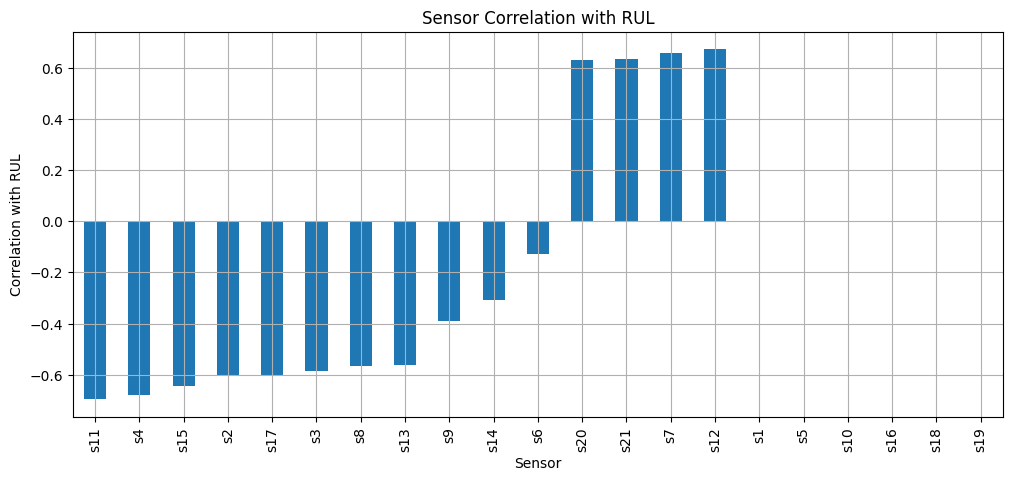

In [7]:
corr.drop("RUL").plot(kind="bar", figsize=(12, 5))

plt.title("Sensor Correlation with RUL")
plt.xlabel("Sensor")
plt.ylabel("Correlation with RUL")
plt.grid(True)
plt.show()

## Sensor Variability Analysis

In this section, we analyze the variability of each sensor.

Sensors with extremely low variance may provide little changing information and can be candidates for removal. However, high variance does not necessarily mean that a sensor is useful, because high variance may also come from noise.

The goal is to identify sensors that are almost constant across the dataset.

In [8]:
sensor_variance = df[sensor_cols].var().sort_values()

sensor_variance

s1     0.000000e+00
s19    0.000000e+00
s18    0.000000e+00
s10    0.000000e+00
s16    1.926023e-34
s5     3.155597e-30
s6     1.929279e-06
s15    1.406628e-03
s8     5.038938e-03
s13    5.172330e-03
s21    1.171825e-02
s20    3.266927e-02
s11    7.133568e-02
s2     2.500533e-01
s12    5.439850e-01
s7     7.833883e-01
s17    2.398667e+00
s3     3.759099e+01
s4     8.101089e+01
s14    3.639005e+02
s9     4.876536e+02
dtype: float64

## Sensor Variance Plot

We visualize sensor variance to identify sensors with very low variability more easily.

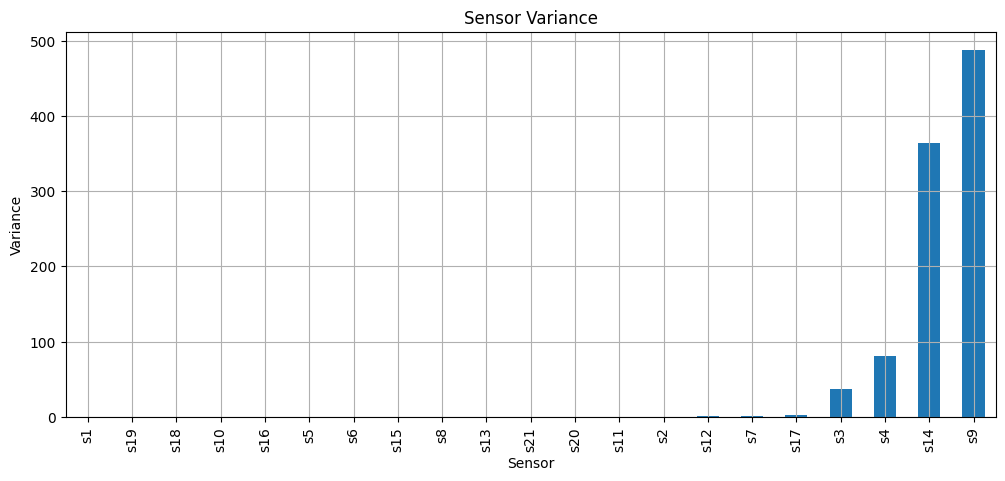

In [9]:
sensor_variance.plot(kind="bar", figsize=(12, 5))

plt.title("Sensor Variance")
plt.xlabel("Sensor")
plt.ylabel("Variance")
plt.grid(True)
plt.show()

## Low-Variance Sensor Candidates

Sensors with very low variance may be less useful for predictive modeling because they do not change much during engine operation.

We inspect the lowest-variance sensors as potential candidates for removal or further review.

In [10]:
low_variance_sensors = sensor_variance[sensor_variance < 1e-5]

low_variance_sensors

s1     0.000000e+00
s19    0.000000e+00
s18    0.000000e+00
s10    0.000000e+00
s16    1.926023e-34
s5     3.155597e-30
s6     1.929279e-06
dtype: float64

## Insight

Some sensors show very low variance, meaning they remain almost constant across the dataset. These sensors may provide limited information for predicting engine degradation.

However, variance alone is not enough to decide whether a sensor is useful. A sensor with high variance may contain useful degradation signals, but it may also contain noise.

Therefore, sensor variance should be used together with other analyses, such as correlation with RUL and visual inspection over engine cycles.

The low-variance analysis supports the correlation results: sensors with near-zero variance also produced NaN correlations with RUL, because constant variables cannot show a meaningful linear relationship.

## Sensor Visualization

### Question

How does a sensor behave throughout the lifetime of a single engine?

### Why are we doing this?

Numerical statistics such as variance and correlation provide valuable information, but they do not reveal the actual behavior of a sensor over time.

By visualizing the sensor values across engine cycles, we can observe trends, stability, noise, and possible degradation patterns that may not be obvious from summary statistics alone.

### Expected Insight

We expect to identify whether the selected sensor shows:

- a clear increasing or decreasing trend,
- a relatively constant behavior,
- high variability (noise),
- or another meaningful degradation pattern.

#### One Engine (id: 1)

In [11]:
# Select one engine
df_id1 = df[df["id"] == 1]

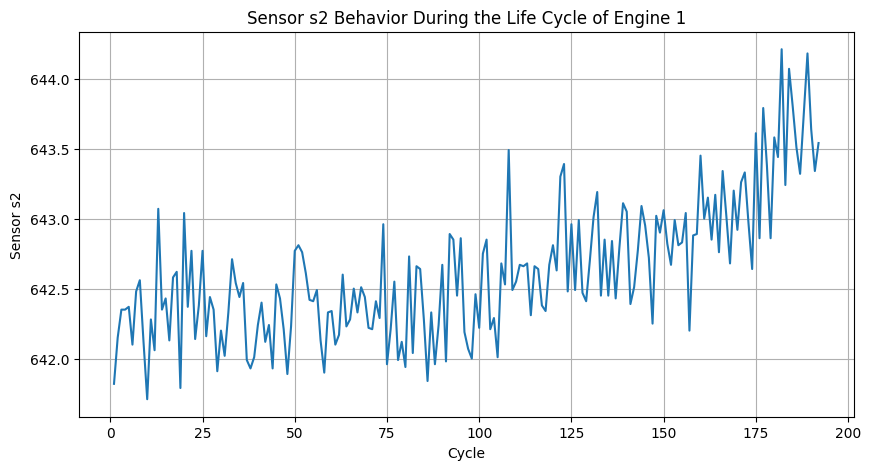

In [ ]:
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    df_id1["cycle"],
    df_id1["s2"]
)

plt.title("Sensor s2 Behavior During the Life Cycle of Engine 1")
plt.xlabel("Cycle")
plt.ylabel("Sensor s2")
plt.grid(True)

plt.show()

### Insight

The `s2` sensor exhibits a gradual upward trend throughout the lifetime of Engine 1, suggesting that its values generally increase as the engine accumulates operating cycles.

Although the signal contains noticeable short-term fluctuations, these variations appear to occur around a consistent upward trend rather than representing purely random noise. This indicates that the sensor may still capture meaningful information related to engine degradation.

Additionally, the increase in sensor values appears to become slightly more pronounced during the later stages of the engine's life. However, this observation is based on a single engine and should be validated by comparing multiple engines before drawing broader conclusions.

### Comparing Sensor s2 Across Multiple Engines

#### Question

Do different engines exhibit similar sensor degradation patterns for sensor `s2`?

#### Method

Three representative engines (1, 10, and 25) were selected and plotted on the same figure. Overlaying multiple engines allows us to compare whether the overall behavior observed for Engine 1 is consistent across different engines.


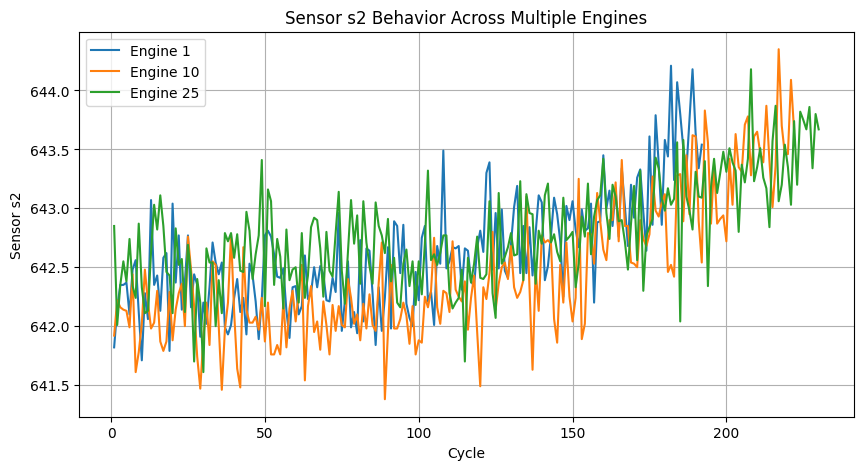

In [ ]:
selected_engines = [1, 10, 25]

plt.figure(figsize=(10, 5))

for engine_id in selected_engines:
    engine_df = df[df["id"] == engine_id]
    plt.plot(
        engine_df["cycle"],
        engine_df["s2"],
        label=f"Engine {engine_id}"
    )

plt.title("Sensor s2 Behavior Across Multiple Engines")
plt.xlabel("Cycle")
plt.ylabel("Sensor s2")
plt.legend()
plt.grid(True)
plt.show()

#### Insight

All three engines exhibit a similar overall upward trend in sensor `s2` as the number of operating cycles increases. Although each engine has its own local fluctuations, the general degradation pattern appears to be consistent across different engines.

The overlaid visualization suggests that sensor `s2` may capture information related to engine degradation rather than random behavior. However, the figure becomes visually crowded, making it difficult to inspect the detailed behavior of individual engines. For detailed analysis, separate plots (subplots) or interactive visualizations would provide better readability.